In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

In [50]:
archivo = r"./file_example_WAV_1MG.wav"

frecuencia_muestreo, audio = wavfile.read( archivo )

audio_normalizado = audio.astype(np.float32) / 32768.0

numero_muestras = len( audio ) 

duracion = numero_muestras / frecuencia_muestreo

C:\Users\uriee\AppData\Local\Temp\ipykernel_3956\1010307523.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  frecuencia_muestreo, audio = wavfile.read( archivo )


## Eje del tiempo 

t = n / fs

In [51]:
tiempo = np.arange( len( audio ) ) / frecuencia_muestreo

## Amplificación de la amplitud

La señal se multiplica por 1.5

In [52]:
factor_amplificacion = 1.5

audio_amplificado = audio_normalizado * factor_amplificacion

audio_amplificado = np.clip( audio_amplificado, -1.0, 1.0 )

## Atenuación de la amplitud

La señal se multiplica por 0.5

In [53]:
factor_atenuacion = 0.5

audio_atenuado = audio_normalizado * factor_atenuacion

## Inversión en el eje de la amplitud

La señal se multiplica por -1

In [54]:
audio_invertido = -audio_normalizado

# Gráficas

Solo se usa el canal izquierdo

In [55]:
original = audio_normalizado[:, 0]

amplificado = audio_amplificado[:, 0]

atenuado = audio_atenuado[:, 0]

invertido = audio_invertido[:, 0]

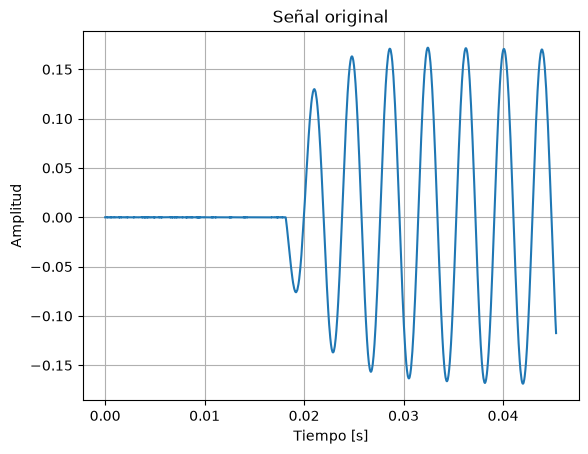

In [56]:
muestras = 2000

tiempo = np.arange(muestras) / frecuencia_muestreo

plt.plot(tiempo, original[:muestras])

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal original")

plt.grid()

plt.show()

### Señal amplificada

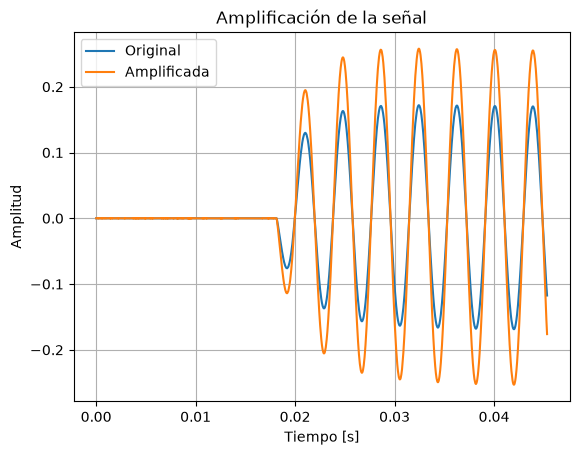

In [57]:
plt.plot(tiempo, original[:muestras], label="Original")
plt.plot(tiempo, amplificado[:muestras], label="Amplificada")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Amplificación de la señal")

plt.legend()
plt.grid()

plt.show()

### Señal atenuada

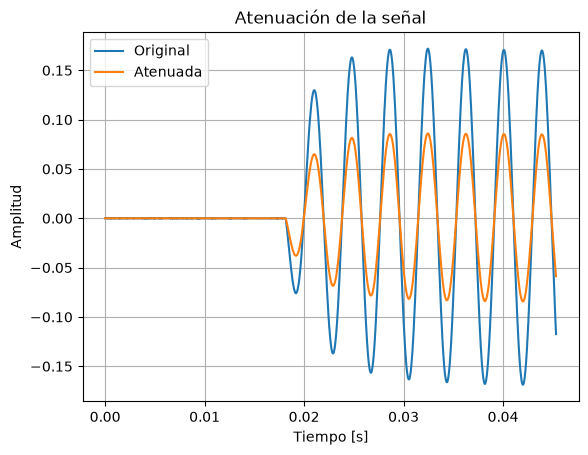

In [58]:
plt.plot(tiempo, original[:muestras], label="Original")
plt.plot(tiempo, atenuado[:muestras], label="Atenuada")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Atenuación de la señal")

plt.legend()
plt.grid()

plt.show()

### Señal invertida

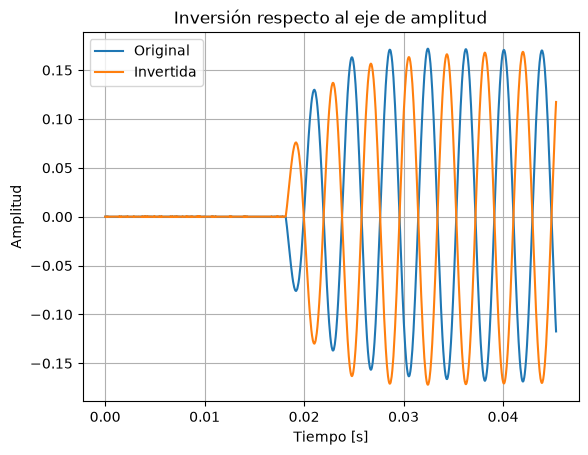

In [59]:
plt.plot(tiempo, original[:muestras], label="Original")
plt.plot(tiempo, invertido[:muestras], label="Invertida")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Inversión respecto al eje de amplitud")

plt.legend()
plt.grid()

plt.show()

## Genera y grafica una señal modificada en frecuencia para compararla respecto a la función original 
Aumento de frecuencia (tono más agudo)

In [60]:
factor_agudo = 2.0

numero_muestras_agudo = int( len ( audio_normalizado ) / factor_agudo )

audio_agudo = signal.resample(
    audio_normalizado,
    numero_muestras_agudo,
    axis=0
)

Disminución de frecuencia (tono más grave)

In [61]:
factor_grave = 0.5

numero_muestras_grave = int( len( audio_normalizado ) / factor_grave )

audio_grave = signal.resample(
    audio_normalizado,
    numero_muestras_grave,
    axis=0
)

Duración de cada señal

In [62]:
duracion_original = len(audio_normalizado) / frecuencia_muestreo

duracion_agudo = len(audio_agudo) / frecuencia_muestreo

duracion_grave = len(audio_grave) / frecuencia_muestreo

print("Duración original:", np.round( duracion_original, 2 ), "s")
print("Duración agudo:", np.round( duracion_agudo, 2 ), "s")
print("Duración grave:", np.round( duracion_grave, 2 ), "s")

Duración original: 5.94 s
Duración agudo: 2.97 s
Duración grave: 11.89 s


Gráficas de las señales modificadas

In [63]:
original = audio_normalizado[:, 0]

agudo = audio_agudo[:, 0]

grave = audio_grave[:, 0]

tiempo_original = np.arange(len(original)) / frecuencia_muestreo

tiempo_agudo = np.arange(len(agudo)) / frecuencia_muestreo

tiempo_grave = np.arange(len(grave)) / frecuencia_muestreo

duracion_grafica = 0.03

# Comparación señal original contra señal aguda

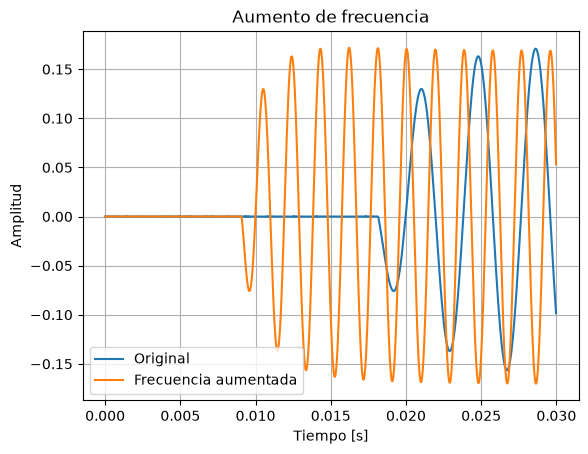

In [64]:
muestras_original = int(duracion_grafica * frecuencia_muestreo)
muestras_agudo = int(duracion_grafica * frecuencia_muestreo)

plt.plot(
    tiempo_original[:muestras_original],
    original[:muestras_original],
    label="Original"
)

plt.plot(
    tiempo_agudo[:muestras_agudo],
    agudo[:muestras_agudo],
    label="Frecuencia aumentada"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Aumento de frecuencia")

plt.legend()
plt.grid()

plt.show()

# Comparación de la señal original contra señal grave

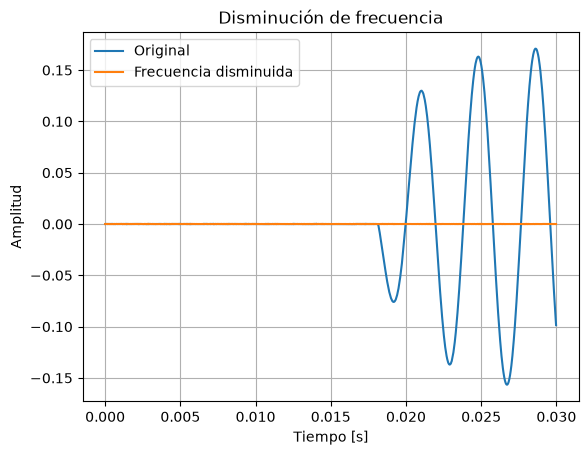

In [65]:
muestras_grave = int(duracion_grafica * frecuencia_muestreo)

plt.plot(
    tiempo_original[:muestras_original],
    original[:muestras_original],
    label="Original"
)

plt.plot(
    tiempo_grave[:muestras_grave],
    grave[:muestras_grave],
    label="Frecuencia disminuida"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Disminución de frecuencia")

plt.legend()
plt.grid()

plt.show()